In [31]:
import os
import importlib
import train_utils
import sanitize

importlib.reload(train_utils)  # 重新加载模块
importlib.reload(sanitize)  # 重新加载模块
os.chdir("c:\\Users\\HANJ29\\Applications\\deepstock\\")

from train_utils import (
    load_train_test_dataset,
    train_model,
    save_model,
    print_fit_report,
    draw_learning_curve,
    print_label_distribution,
    save_training_results, plot_histograms,test_data_distribution
)

from sanitize import get_train_test_data


freq = "D"
version = "0.1"
model_name = "RF"
labels = [
    "top_or_bottom",
    "top_or_bottom_stat",
    "top_bottom_volatility_stat",
    "top_or_bottom_optimized",
    "top_or_bottom_stat_optimized",
    "top_bottom_volatility_optimized",
]

dataset_load_features = [
    "ts_code",
    "trade_date",
    "open",
    "high",
    "low",
    "close",
    "pre_close",
    "pct_change",
    "vol",
    "amount",
    "atr",
    "boll_upper",
    "boll_mid",
    "boll_lower",
    "pct_vol_chg",
    "pct_amount_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "cci",
    "mab_6",
    "mab_10",
    "mab_25",
    "mab_60",
    "mab_120",
    "mab_200",
    "is_lower_shadow_shape",
    "is_upper_shadow_shape",
    "is_doji_shape",
    "is_big_bullish",
    "is_bullish_divergent",
    "is_big_bearish",
    "is_support_ma_6",
    "is_support_ma_10",
    "is_support_ma_25",
    "is_support_ma_60",
    "is_support_ma_120",
    "is_support_ma_200",
    "ma_6_trend",
    "ma_10_trend",
    "ma_25_trend",
    "ma_60_trend",
    "ma_120_trend",
    "ma_200_trend",
    "is_ma_entangled_6_10",
    "is_ma_entangled_25_200",
    "is_ma_entangled_6_10_25",
    "is_ma_entangled_6_10_200",
    "is_ma_entangled_6_10_25_60_120_200",
    "vol_status_ma",
    "vol_status_ma10",
    "kdj_status",
    "rsi_status",
    "macd_status",
    "is_t_shape",
    # "top_or_bottom",
    # "top_or_bottom_stat",
    # "top_bottom_volatility_stat",
    # "top_or_bottom_stat_optimized",
    # "top_or_bottom_optimized",
    # "top_bottom_volatility_optimized",
]

train_input_features = [
    "atr",
    "boll_upper",
    "boll_mid",
    "boll_lower",
    "pct_vol_chg",
    "pct_amount_chg",
    "pct_o2c",
    "lower_shadow",
    "upper_shadow",
    "dif",
    "dea",
    "bar",
    "rsi_6",
    "rsi_12",
    "rsi_24",
    "k",
    "d",
    "j",
    "cci",
    "mab_6",
    "mab_10",
    "mab_25",
    "mab_60",
    "mab_120",
    "mab_200",
    "is_lower_shadow_shape",
    "is_upper_shadow_shape",
    "is_doji_shape",
    "is_big_bullish",
    "is_bullish_divergent",
    "is_big_bearish",
    "is_support_ma_6",
    "is_support_ma_10",
    "is_support_ma_25",
    "is_support_ma_60",
    "is_support_ma_120",
    "is_support_ma_200",
    "ma_6_trend",
    "ma_10_trend",
    "ma_25_trend",
    "ma_60_trend",
    "ma_120_trend",
    "ma_200_trend",
    "is_ma_entangled_6_10",
    "is_ma_entangled_25_200",
    "is_ma_entangled_6_10_25",
    "is_ma_entangled_6_10_200",
    "is_ma_entangled_6_10_25_60_120_200",
    "vol_status_ma",
    "vol_status_ma10",
    "kdj_status",
    "rsi_status",
    "macd_status",
    "is_t_shape",
]

In [32]:
# 加载数据集
import pandas as pd

env = "DEV"
root_path = os.getcwd()

stock_filestore_DEV = f"C:/Users/HANJ29/Applications/btweb/stock_filestore/{env}/"
dataset_training = f"{stock_filestore_DEV}dataset_training/"

In [33]:
tech_df = pd.read_csv(f"{dataset_training}mapped_tech_pattern_D.csv", dtype=str)
print("tech_df loaded")
# 获取训练和测试数据
tech_df

tech_df loaded


,ts_code,trade_date,open,high,low,close,pre_close,pct_change,vol,amount,...,kdj_status,rsi_status,macd_status,is_t_shape,top_or_bottom,top_or_bottom_stat,top_bottom_volatility_stat,top_or_bottom_stat_optimized,top_or_bottom_optimized,top_bottom_volatility_optimized
0,000001.SZ,1992-03-03,0.59214,0.59307,0.58749,0.59028,0.59028,0.0,3150.0,9984.0,...,0,0,0,0,1,0,0,0,1,0
1,000001.SZ,1992-03-04,0.59214,0.594,0.58749,0.59121,0.59028,0.16,2288.0,7248.0,...,0,0,0,0,0,0,0,0,0,0
2,000001.SZ,1992-03-05,0.59028,0.59587,0.58935,0.59494,0.59121,0.63,2733.0,8699.0,...,0,0,0,0,0,0,0,0,0,0
3,000001.SZ,1992-03-06,0.59587,0.60145,0.59307,0.59773,0.59494,0.47,4260.0,13654.0,...,1,0,0,0,0,0,0,0,0,0
4,000001.SZ,1992-03-09,0.60052,0.61263,0.60052,0.60332,0.59773,0.93,3515.0,11455.0,...,1,0,0,0,2,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2792667,001222.SZ,2025-06-20,19.88,20.43,19.79,19.83,19.95,-0.6015,45489.8,90992.54,...,0,0,1,0,0,0,0,0,0,0
2792668,001222.SZ,2025-06-23,19.79,20.48,19.54,19.89,19.83,0.3026,49211.2,98012.46,...,0,0,1,0,2,0,0,0,0,0
2792669,001222.SZ,2025-06-24,20.1,21.04,19.95,20.42,19.89,2.6647,75317.8,155035.77,...,0,0,1,0,0,0,0,0,0,0
2792670,001222.SZ,2025-06-25,20.65,21.09,19.92,20.1,20.42,-1.5671,62527.89,126904.16,...,2,0,1,0,2,2,0,2,2,0


In [4]:
train, test = get_train_test_data(df=tech_df, dataset_training_path=dataset_training,)

train_dataset_tech_D_0.1.csv and test_dataset_tech_D_0.1.csv saved


In [5]:
X_train, X_test, y_train, y_test = load_train_test_dataset(
    filter_by="ts_code",
    dtype="tech",
    freq=freq,
    version=version,
    features=dataset_load_features,
    training_path=dataset_training,
)

Train dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/train_dataset_tech_D_0.1.csv
Test dataset loaded from C:/Users/HANJ29/Applications/btweb/stock_filestore/DEV/dataset_training/test_dataset_tech_D_0.1.csv
split train data to X and y
X_train shape: (1954648, 62), y_train shape: 6
split test data to X and y
X_test shape: (838024, 62), y_test shape: 6


In [6]:
# 计算额外的特征
X_test['volatility_ratio'] = X_test['pct_vol_chg'] / (X_test['atr'] + 1e-5)
X_test['shadow_ratio'] = X_test['lower_shadow'] / (X_test['upper_shadow'] + 1e-5)
X_test["boll_upper_ratio"] = X_test["high"] - X_test["boll_upper"]
X_test["boll_lower_ratio"] = X_test["low"] - X_test["boll_lower"]
X_test["boll_mid_ratio"] = X_test["low"] - X_test["boll_mid"]

# 计算额外的特征
X_train['volatility_ratio'] = X_train['pct_vol_chg'] / (X_train['atr'] + 1e-5)
X_train['shadow_ratio'] = X_train['lower_shadow'] / (X_train['upper_shadow'] + 1e-5)
X_train["boll_upper_ratio"] = X_train["high"] - X_train["boll_upper"]
X_train["boll_lower_ratio"] = X_train["low"] - X_train["boll_lower"]
X_train["boll_mid_ratio"] = X_train["low"] - X_train["boll_mid"]

In [7]:
X_train = X_train[train_input_features]
X_test = X_test[train_input_features]

In [ ]:
# 训练模型
# Current label distribution:
# top_or_bottom_optimized
# 0    268571
# 2     72591
# 1     72369900000000000000000o
def get_hyper_param(param_name):
    # 定义随机森林分类器的超参数
    RF = {
        "n_estimators":1000,                # 减少树的数量（原100,少数类精度低）
        "max_depth":None,                    # 限制树深（原50→10）
        "min_samples_split":10,            # 提高分裂门槛（原10→50）
        "min_samples_leaf":5,             # 增加叶子节点样本数（原5→20）
        "max_features":'sqrt',             # 保持特征采样策略
        "class_weight":{0:1, 1:7, 2:7},    # 增加少数类权重（原2→4，平衡4:1的分布）
        "random_state":42,
        "n_jobs":-1,
        "bootstrap":True,                  # 使用自助采样
        "oob_score":True,                   # 使用袋外数据评估泛化能力
        "verbose": 1,  # 输出详细信息
    }

    # 定义超参数字典
    XGB = {
        "n_estimators": 5000,  # 如果过拟合，可以适当增加
        "learning_rate": 0.1,  # 如果过拟合，可以适当减小；反之亦然
        "max_depth": 5,  # 如果过拟合，可以适当减小；反之亦然
        "min_child_weight": 1,  # 如果过拟合，可以适当增大；反之亦然
        "gamma": 0,  # 如果过拟合，可以适当增大；反之亦然
        #"subsample": 0.8,  # 如果过拟合，可以适当减小；反之亦然
        #"colsample_bytree": 0.8,  # 如果过拟合，可以适当减小；反之亦然
        #"reg_alpha": 10,  # 如果过拟合，可以适当增大；反之亦然
        #"reg_lambda": 20,  # 如果过拟合，可以适当增大；反之亦然
        "objective": "multi:softmax",  # 多分类
        # "num_class": 3,  # 类别数
        "eval_metric": "mlogloss",#"mlogloss",  # 评价指标
        # "early_stopping_rounds": 50, #早停轮数
        # "use_label_encoder": False,  # 避免警告
        "random_state": 42,  # 随机种子
        "n_jobs": -1,  # 使用所有可用 CPU 核心进行并行计算
        "verbosity": 1,  # 输出详细信息
    }
    # 超参数
    LGBM = {
        "objective": "multiclass",  # 多分类问题
        "num_class": 3,  # 类别数量（根据实际类别数调整）
        "learning_rate": 0.05,  # 初始学习率
        "max_depth": -1,  # 不限制树的深度，观察是否过拟合
        "num_leaves": 31,  # 每棵树的最大叶子数，控制模型复杂度
        "min_data_in_leaf": 20,  # 每个叶子节点的最小样本数，防止过拟合
        "feature_fraction": 0.8,  # 每棵树使用的特征比例
        "bagging_fraction": 0.8,  # 每棵树使用的样本比例
        "bagging_freq": 5,  # 每 5 次迭代进行一次样本重采样
        "lambda_l1": 0.0,  # L1 正则化
        "lambda_l2": 0.0,  # L2 正则化
        "n_estimators": 5000,  # 500,#200,          # 初始树的数量
        "class_weight": {0: 1, 1: 3, 2: 3},  # 类别权重，防止过拟合
        "random_state": 42,  # 固定随机种子
        "n_jobs": -1,  # 使用所有 CPU 核心
    }
    # 定义超参数字典
    CAT = {
        "loss_function": "MultiClass",  # 多分类问题
        "learning_rate": 0.1,  # 初始学习率
        "depth": 6,  # 树的深度，控制模型复杂度
        "iterations": 1000,  # 最大迭代次数（树的数量）
        "l2_leaf_reg": 3,  # L2 正则化系数，防止过拟合
        "border_count": 32,  # 特征分箱的边界数量，默认 32
        "random_strength": 1,  # 控制分裂时的随机性，防止过拟合
        "bagging_temperature": 1,  # 控制样本权重的随机性，1 为默认值
        "class_weights": {0: 1, 1: 3, 2: 3},  # 类别权重，若类别不平衡可设置
        "random_seed": 42,  # 固定随机种子
        "thread_count": -1,  # 使用所有 CPU 核心
    }
    local_vars = locals()
    if param_name in local_vars:
        return local_vars[param_name]
    else:
        raise ValueError(f"Parameter '{param_name}' not found.")

model_name = "XGB"
label = "top_or_bottom_optimized"    
params = get_hyper_param(model_name)
params

{'n_estimators': 1000,
 'learning_rate': 0.01,
 'max_depth': 6,
 'min_child_weight': 10,
 'gamma': 1,
 'objective': 'multi:softmax',
 'num_class': 3,
 'eval_metric': 'mlogloss',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': 1}

In [24]:
# 计算类别权重
class_counts = y_train[label].value_counts().to_dict()
n_classes = len(class_counts)
total = sum(class_counts.values())
class_weight = {k: total/(n_classes*v) for k, v in class_counts.items()}
sample_weight = y_train[label].map(class_weight)

In [25]:
from datetime import datetime
start_time = datetime.now()
print(f"Starting model training...{start_time}")
# 训练模型
# params = {"sample_weight": sample_weights}
print(params)
model = train_model(
    X_train=X_train, y_train=y_train[label], model_name=model_name, 
    **params, sample_weight=sample_weight,
)
print("Model training complete.")
end_time = datetime.now()
time_diff = end_time - start_time
print(f"Model training end time: {end_time}, total time {time_diff}")
print("Model training complete.")
print(f"Starting model training...")

Starting model training...2025-07-01 21:06:22.971552
{'n_estimators': 1000, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 10, 'gamma': 1, 'objective': 'multi:softmax', 'num_class': 3, 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1, 'verbosity': 1}
Model training complete.
Model training end time: 2025-07-01 21:22:03.669750, total time 0:15:40.698198
Model training complete.
Starting model training...


In [ ]:
# del model

In [26]:
print("Fit Report:")
report_metrics_train = print_fit_report(model, X_train, y_train[label])

Fit Report:
Recall (weighted): 0.4605
              precision    recall  f1-score   support

           0       0.89      0.38      0.53   1510785
           1       0.24      0.74      0.36    221902
           2       0.26      0.73      0.38    221961

    accuracy                           0.46   1954648
   macro avg       0.46      0.62      0.43   1954648
weighted avg       0.74      0.46      0.50   1954648



In [22]:
print("Model Evaluation Report:")
report_metrics_test = print_fit_report(model, X_test, y_test[label])

Model Evaluation Report:
Recall (weighted): 0.7763
              precision    recall  f1-score   support

           0       0.78      0.99      0.87    649803
           1       0.58      0.01      0.02     94131
           2       0.54      0.04      0.08     94090

    accuracy                           0.78    838024
   macro avg       0.63      0.35      0.32    838024
weighted avg       0.73      0.78      0.69    838024



In [ ]:
print("Start Drawing Learning Curve")
draw_learning_curve(model, X_train, y_train[label], cv=3, scoring=None, title="Learning Curve")

In [ ]:
# 假设 model 是你的随机森林模型，input_features 是特征名列表

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': dataset_load_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df)

                               feature  importance
26                                 cci    0.054783
16                        upper_shadow    0.050546
15                        lower_shadow    0.050471
5                           pct_change    0.039964
13                      pct_amount_chg    0.039140
..                                 ...         ...
61                          is_t_shape    0.000771
37                is_bullish_divergent    0.000594
52              is_ma_entangled_25_200    0.000575
54            is_ma_entangled_6_10_200    0.000207
55  is_ma_entangled_6_10_25_60_120_200    0.000001

[62 rows x 2 columns]


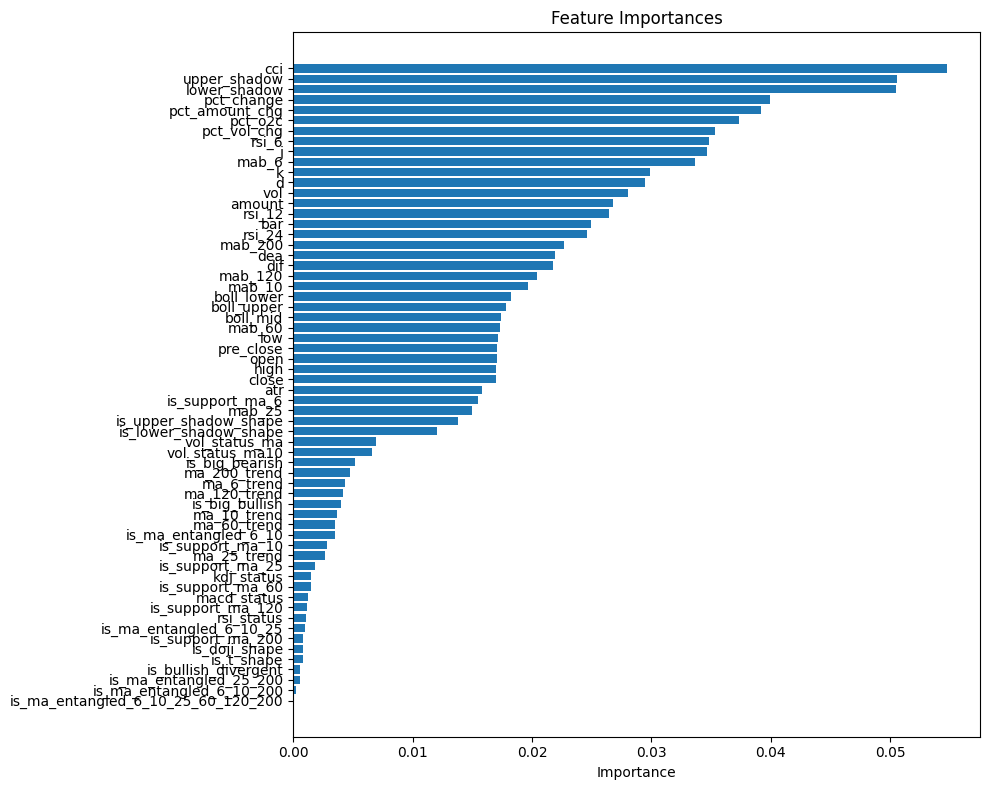

In [48]:
import matplotlib.pyplot as plt

# 假设 feature_importance_df 已经按 importance 排好序
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances')
plt.gca().invert_yaxis()  # 让重要性高的特征在上面
plt.tight_layout()
plt.show()

In [16]:
import joblib


# 加载模型
model_name = "XGB"  # 替换为你的模型名称
freq = "D"  # 替换为你的频率
pred_type = "STDOPT"  # 替换为你的预测类型

# 调用自定义的加载函数
saved_model = joblib.load(
    r"C:\Users\HANJ29\Applications\DEPLOYMENT\PROD\web\btweb\stock_filestore\PROD\models\MIXED\1.0\\"
    + model_name
    + "_"
    + pred_type
    + "_"
    + freq
    + ".model"
)


In [11]:
if hasattr(saved_model, "feature_importances_"):
    print(saved_model.feature_importances_)
else:
    print("The model does not have feature_importances_ attribute.")

[0.01056633 0.01620088 0.01055755 0.0099756  0.05781357 0.02731592
 0.08233934 0.08901617 0.01272101 0.01002435 0.0125254  0.03518048
 0.01164881 0.01119229 0.0167974  0.03116927 0.05020157 0.01143072
 0.01312176 0.0186504  0.00919387 0.00803999 0.00806174 0.00835528
 0.00938935 0.00843377 0.01015538 0.01102005 0.00801141 0.02894811
 0.01465183 0.03059811 0.27227604 0.01279592 0.01041772 0.01120264]


In [12]:
print(type(saved_model))

<class 'xgboost.sklearn.XGBClassifier'>


In [29]:
{'n_estimators': 5000, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'gamma': 0, 'objective': 'multi:softmax', 'eval_metric': 'mlogloss', 'random_state': 42, 'n_jobs': -1, 'verbosity': 1}


{'n_estimators': 5000,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'gamma': 0,
 'objective': 'multi:softmax',
 'eval_metric': 'mlogloss',
 'random_state': 42,
 'n_jobs': -1,
 'verbosity': 1}

In [30]:
saved_model.feature_weights

AttributeError: 'XGBClassifier' object has no attribute 'feature_weights'

In [7]:
# 输出模型的训练参数
if hasattr(saved_model, "get_params"):
    params = saved_model.get_params()
    print("Model Training Parameters:")
    for param, value in params.items():
        print(f"{param}: {value}")
else:
    print("The model does not support parameter retrieval.")

# 输出特征重要性
if hasattr(saved_model, "feature_importances_"):
    print("\nFeature Importances:")
    print(saved_model.feature_importances_)
else:
    print("The model does not have feature_importances_ attribute.")

AttributeError: 'XGBModel' object has no attribute 'feature_weights'